# 03 — How cheaply can the saturation rule select a mask?

Notebook 02 measured selection quality. Here we measure the work needed to obtain those masks. Paper uses the pinned submodule's C++ selector; saturation tiles and Top-$R$ are implemented in [selectors.cpp](selectors.cpp). Python only prepares inputs, calls the kernels, checks their results, and plots the measurements.

The selection boundary is a prepared CPU importance vector to a CPU mask. With `RUN_CUDA = True`, compare CPU sorting with Paper's hybrid CUDA-sort path and measure packed GPU matmul on the same machine. The final section adds these measurements to Notebook 02's modeled read cost. This is a projection-level composed estimate, not an observed inference wall time. The oracle is not timed.

In [2]:
from pathlib import Path
from time import perf_counter_ns
from IPython.display import Markdown, display
import json, os, platform, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL = Path("../01/latency_model.json")
TRACE = Path("../02/activation_traces.npz")
QUALITY = Path("../02/oracle_results_fixed_r.csv")
UPSTREAM = Path("../../../upstream/vlm-flash")
RESULTS = Path("selection_results.csv")
ENVIRONMENT = Path("environment.json")
RUN_BENCHMARK = False
RUN_CUDA = False  # True: also measure Paper GPU sort and packed CUDA matmul.
if RUN_CUDA:
    RESULTS, ENVIRONMENT = Path("selection_cuda_results.csv"), Path("environment_cuda.json")
MAX_TRACES_PER_SHAPE = 32
BUDGETS = np.arange(1, 10) / 10
WARMUP, REPEATS = 5, 31

## Keep quality fixed while measuring selection time.

For case $j=(v,R)$ and method $m$, time one native call:

$$t_{j,m,r}=t_{\mathrm{return}}-t_{\mathrm{call}},\qquad
\widehat t_{j,m}=\operatorname{median}_{r=1,\ldots,31}t_{j,m,r}.$$

All methods receive the same contiguous CPU float32 vector and requested $R$. Tiles and Top-$R$ select exactly $R$; Paper retains its reference underfill rule. We check the masks against Notebook 02 before timing and carry over its quality and fill diagnostics. A tied mask may differ only if its selected count, importance, and merged-run cost agree.

The timed Paper entry point is the **unchanged native kernel**. `Paper CPU` passes `cuda_sort=False`; `Paper GPU sort` passes `True`. In the latter, CPU prefix sums and candidates precede score upload, CUDA stable sort, index download, and CPU greedy selection, as in [Appendix E](https://openreview.net/pdf?id=3xwsD68F2K) and the checked-out native source. Its window sizes, costs, and stride are resolved by upstream code before timing, since they do not depend on $v$. Candidate scoring, sorting, overlap checks, mask allocation, and output construction remain timed. The public Python policy wrapper, importance extraction, compilation, and disk reads are excluded. Score/index transfers inside the hybrid kernel are included; the initial GPU-activation transfer and final GPU-mask transfer are not. Both Paper variants return a CPU mask, as do the unchanged C++ tiles and Top-$R$. Binding and timer overhead are included.

In [3]:
if RUN_BENCHMARK:
    import torch
    if RUN_CUDA:
        assert torch.cuda.is_available(), "RUN_CUDA requires CUDA PyTorch and a visible GPU; no CPU fallback."
        torch.cuda.init()
        torch.cuda.synchronize()
    from torch.utils.cpp_extension import load
    os.environ.setdefault("MAX_JOBS", "1")
    torch.set_num_threads(1)
    sys.path.insert(0, str((UPSTREAM / "src").resolve()))
    import vlmflash
    from vlmflash._native import native
    from vlmflash.policy import _window_sweep
    assert Path(vlmflash.__file__).resolve().is_relative_to(UPSTREAM.resolve())
    paper_native = native()
    assert paper_native is not None, "Build the reference native extension first."
    selectors = load("vlmflash_selection03", [str(Path("selectors.cpp").resolve())],
                     extra_cflags=["-O3", "-std=c++17"], verbose=False)

## Tiles need a selected set, not a complete ranking.

The rule is unchanged from Notebook 02. Put $B=\lceil s\rceil$, $k=\lfloor R/B\rfloor$, and $r=R\bmod B$. At offsets $0$ and $\lfloor B/2\rfloor$, select the $k$ full tiles with the largest importance, then the best disjoint length-$r$ interval. Choose between the two masks using the same merged-run $I/L$. If $R<B$, select the best contiguous $R$-run.

For $m$ disjoint tile candidates, only membership in the largest $k$ is needed. C++ `std::nth_element` replaces the full sort; ties prefer the earlier tile. This gives average $O(m)$ partial-selection work, rather than $O(m\log m)$ full sorting. Prefix sums, residual scanning, and mask construction remain $O(N)$. This is not a worst-case linear-time claim for `nth_element`, nor a guarantee of a speedup.

Paper's overlapping multiscale candidate set and greedy pass are left untouched. Its extra work and the quality it gains are the quantities being compared.

In [4]:
if RUN_BENCHMARK:
    model = json.loads(MODEL.read_text())
    s_kib, c1, delta, s99 = (model[k] for k in
        ("s_kib", "c1_ms_per_kib", "delta_ms_per_kib", "s99_kib"))
    table = vlmflash.LatencyTable({z: c1*z + delta*max(s_kib, z)
        for z in range(1, int(np.ceil(max(s_kib, s99))) + 2)})
    with np.load(TRACE, allow_pickle=False) as archive:
        manifest = json.loads(str(archive["manifest_json"].item()))
        traces = [{**t, "values": archive[t["array"]].astype(float)} for t in manifest["traces"]]
    if MAX_TRACES_PER_SHAPE:
        groups = [[t for t in traces if t["shape"] == shape] for shape in sorted({t["shape"] for t in traces})]
        traces = [g[i] for g in groups for i in np.linspace(
            0, len(g)-1, min(len(g), MAX_TRACES_PER_SHAPE), dtype=int)]
    traces.sort(key=lambda t: t["trace_id"])
    weight_bytes = {"float16": 2, "bfloat16": 2, "float32": 4}[manifest["model_dtype"]]
    if RUN_CUDA:
        assert all(t["num_tokens"] > 0 for t in traces), "Captured token counts are required."
        assert manifest["model_dtype"] in ("float16", "bfloat16", "float32")
        assert manifest["model_dtype"] != "bfloat16" or torch.cuda.is_bf16_supported()
    quality = pd.read_csv(QUALITY)
    quality["fraction"] = quality.fraction.round(6)
    quality = quality.set_index(["trace_id", "fraction", "method"])
    geometry = {"896x128": (8,8), "896x896": (8,8), "896x4864": (8,8), "4864x896": (12,16)}

## Interleave the methods and keep the individual timings.

Each case has five warm-up rounds, followed by 31 timed rounds. A fixed random seed changes method order in each round. Inputs are reused; masks and scores are recomputed on every call. Both extensions use the same compiler and `-O3`; Torch uses one CPU thread. In CUDA mode, synchronize before each call, outside the timer. The hybrid kernel's blocking index copy back to CPU completes its GPU sort before return; the timer includes that round trip. Warm-up includes the actual sort path.

Per-case medians and 95th percentiles describe the observed calls, not confidence intervals. Speedups are paired within each case before aggregation. The saved samples and environment identify this run; timings on a shared host do not establish deployment performance. Set both `RUN_BENCHMARK = True` and `RUN_CUDA = True` for the new experiment. CPU and hybrid selection are remeasured together, then GEMM is timed locally; earlier CPU timings are not mixed into this run. CUDA mode writes `selection_cuda_results.csv` and `environment_cuda.json`, leaving the legacy files untouched. To replay, keep `RUN_CUDA = True` and set `RUN_BENCHMARK = False`. CUDA absence fails before measurement, not under a GPU label.

In [5]:
if RUN_BENCHMARK:
    rng, records = np.random.default_rng(0), []
    for i, trace in enumerate(traces, 1):
        v = trace["values"]
        v = (v / v.mean()).astype(np.float32) if v.any() else v.astype(np.float32)
        values, N = torch.from_numpy(v), len(v)
        w = weight_bytes * trace["d"] / 1024
        s, b1, b2 = s_kib/w, w*c1, w*(c1+delta)
        length = np.arange(N+1)
        T = b2*length + (b2-b1)*np.maximum(s-length, 0)
        T[0] = 0
        costs = torch.from_numpy(T)
        start, jump = geometry[trace["shape"]]
        params = vlmflash.ChunkParams(start_kb=start, step_kb=start, jump_cap_kb=jump, end_kb=s99+1)
        windows, stride = _window_sweep(N, w, table, params)
        sizes = torch.tensor([z for z, _ in windows], dtype=torch.int64)
        delays = torch.tensor([t for _, t in windows], dtype=torch.float64)
        for fraction in BUDGETS:
            R = max(1, int(fraction*N))
            functions = {
                "Paper CPU": lambda: paper_native.select_chunks(values, R, sizes, delays, stride, False),
                "Saturation tiles": lambda: selectors.tiles(values, R, costs, int(np.ceil(s))),
                "Top-R": lambda: selectors.top_r(values, R, costs),
            }
            if RUN_CUDA:
                functions["Paper GPU sort"] = lambda: paper_native.select_chunks(values, R, sizes, delays, stride, True)
            checked = {}
            for name, fn in functions.items():
                mask = fn()[0].numpy().astype(bool)
                reference = "Paper greedy" if name.startswith("Paper") else name
                old = quality.loc[(trace["trace_id"], round(float(fraction),6), reference)]
                expected = np.zeros(N, bool)
                for a, b in json.loads(old.intervals): expected[a:b] = True
                spans = np.flatnonzero(np.diff(np.r_[False, mask, False])).reshape(-1,2)
                I, L = v.astype(float)[mask].sum(), T[np.diff(spans, axis=1).ravel()].sum()
                assert mask.sum() == old.R_selected
                assert mask.sum() <= R if name.startswith("Paper") else mask.sum() == R
                np.testing.assert_allclose([I,L], [old.importance,old.latency], rtol=1e-10, atol=1e-12)
                checked[name] = (old, np.array_equal(mask, expected))
            samples = {name: [] for name in functions}
            names = list(functions)
            for repeat in range(WARMUP + REPEATS):
                for j in rng.permutation(len(names)):
                    name = names[j]
                    fn = functions[name]
                    if RUN_CUDA: torch.cuda.synchronize()
                    begin = perf_counter_ns()
                    result = fn()
                    elapsed = (perf_counter_ns() - begin) / 1000
                    if repeat >= WARMUP: samples[name].append(elapsed)
            for name, times in samples.items():
                old, matches = checked[name]
                records.append(dict(trace_id=trace["trace_id"], shape=trace["shape"],
                    fraction=float(fraction), R_nominal=R, R_selected=int(old.R_selected), method=name,
                    cuda_sort=name == "Paper GPU sort", num_tokens=int(trace["num_tokens"]),
                    d=int(trace["d"]), dtype=manifest["model_dtype"],
                    median_us=np.median(times), p95_us=np.percentile(times,95),
                    gap_upper_pct=old.gap_upper_pct, fill_pct=old.fill_pct,
                    mask_matches_02=matches, samples_us=json.dumps(times)))
        pd.DataFrame(records).to_csv(RESULTS,index=False)
        if i % 16 == 0 or i == len(traces): print(f"{i}/{len(traces)} traces measured")

## Measure the multiplication used by the flash path.

The checked-out [`SparseLinear.forward`](../../../upstream/vlm-flash/src/vlmflash/linear.py) uses `x[..., mask] @ w_rows.to(x.dtype)` after reading the selected, transposed weight rows. Its in-memory path instead masks activations before a full dense linear operation. We time the **packed flash-path multiplication**, not that dense path:

$$A\in\mathbb R^{p\times K},\quad B\in\mathbb R^{K\times d},\quad Y=AB,\qquad K=|M|,\quad \mathrm{FLOPs}\simeq2pKd.$$

Here $p$ is the trace's archived token count and $d$ its output width; dtype also comes from the archive. Paper's underfilled mask uses its own $K$, not nominal $R$. Random dense operands stand in for already packed activations and resident weight rows. Their values are synthetic; the dimensions are not. No checkpoint is loaded.

One warmed measurement per distinct $(p,K,d,\mathrm{dtype})$ is shared across matching cases. Each sample is a synchronized host-wall interval around `A @ B`, including launch and output allocation. Operand preparation is outside the timer. These are isolated packed-GEMM costs, not complete forward times; equal shapes share the same estimate by construction. [CUDA synchronization](https://docs.pytorch.org/docs/2.10/notes/cuda.html#asynchronous-execution) is necessary because GPU launches are asynchronous.

In [6]:
def matmul_samples(tokens, selected, width, dtype, device="cuda"):
    sync = torch.cuda.synchronize if device == "cuda" else lambda: None
    with torch.inference_mode():
        a = torch.randn(tokens, selected, dtype=dtype, device=device)
        b = torch.randn(selected, width, dtype=dtype, device=device)
        samples = []
        for repeat in range(WARMUP + REPEATS):
            sync()
            begin = perf_counter_ns()
            y = a @ b
            sync()
            elapsed = (perf_counter_ns() - begin) / 1e6
            if repeat >= WARMUP: samples.append(elapsed)
    return samples


if RUN_BENCHMARK and RUN_CUDA:
    torch.manual_seed(0)
    torch.backends.cuda.matmul.allow_tf32 = False
    measured = pd.DataFrame(records)
    dimensions = ["num_tokens", "R_selected", "d", "dtype"]
    compute = []
    for key in measured[dimensions].drop_duplicates().itertuples(index=False, name=None):
        p, k, d, dtype = key
        samples = matmul_samples(p, k, d, getattr(torch, dtype))
        compute.append(dict(zip(dimensions, key), matmul_ms=np.median(samples),
            matmul_p95_ms=np.percentile(samples, 95), matmul_samples_ms=json.dumps(samples)))
    measured = measured.merge(pd.DataFrame(compute), on=dimensions, how="left", validate="many_to_one")
    assert measured.matmul_ms.notna().all() and (measured.matmul_ms > 0).all()
    measured.to_csv(RESULTS, index=False)

In [7]:
if RUN_BENCHMARK:
    cpu = next((s.split(":",1)[1].strip() for s in Path("/proc/cpuinfo").read_text().splitlines()
                if s.startswith("model name")), platform.machine())
    environment = dict(platform=platform.platform(), cpu=cpu, python=platform.python_version(),
        torch=torch.__version__, compiler=subprocess.check_output([os.environ.get("CXX","c++"),"--version"],text=True).splitlines()[0],
        flags="-O3; C++17", torch_threads=torch.get_num_threads(), cuda_sort=RUN_CUDA,
        cuda_runtime=torch.version.cuda, gpu=torch.cuda.get_device_name() if RUN_CUDA else None,
        matmul_dtype=manifest["model_dtype"] if RUN_CUDA else None,
        matmul_tf32=False if RUN_CUDA else None,
        traces=len(traces), budgets=list(BUDGETS), warmup=WARMUP, repeats=REPEATS,
        notebook_base="78c1bc3074f1147da29aabc8b4427f450260265f", upstream_commit="9023679ebfd1900fa2912c4098f51bfb9efa7bb8")
    ENVIRONMENT.write_text(json.dumps(environment,indent=2))
frame = pd.read_csv(RESULTS) if RESULTS.is_file() else pd.DataFrame()
if ENVIRONMENT.is_file(): display(pd.Series(json.loads(ENVIRONMENT.read_text())))
if not frame.empty and "cuda_sort" not in frame:
    display(Markdown("Legacy run: sort mode was not recorded per method; its old `cuda_sort` metadata is not reliable. Rerun to identify CPU and GPU-sort timings."))
paper_methods = [name for name in ("Paper CPU", "Paper GPU sort", "Paper greedy") if not frame.empty and name in set(frame.method)]

platform           Linux-7.2.5-200.fc44.x86_64-x86_64-with-glibc2.43
cpu                       AMD Ryzen 7 8845HS w/ Radeon 780M Graphics
python                                                       3.13.11
torch                                                   2.11.0+cu130
compiler                c++ (GCC) 16.2.1 20260819 (Red Hat 16.2.1-2)
flags                                                     -O3; C++17
torch_threads                                                      1
cuda_sort                                                      False
traces                                                           128
budgets                [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
warmup                                                             5
repeats                                                           31
source_commit               cc4f8c589716fbcaee186cc9f2b928193d25a65e
upstream_commit             9023679ebfd1900fa2912c4098f51bfb9efa7bb8
dtype: object

Legacy run: sort mode was not recorded per method; its old `cuda_sort` metadata is not reliable. Rerun to identify CPU and GPU-sort timings.

## Compare selection time on the same cases.

$$S_j=\frac{\widehat t_{j,\mathrm{Paper}}}{\widehat t_{j,\mathrm{Tiles}}}.$$

A value above one favors tiles; compute it separately for each Paper variant. This is selection speed, not flash-read speed. Paper's smaller realized mask is preserved and its fill percentage remains visible. Ratios of shape-level medians are not substituted for the median of the paired speedups.

method,Paper greedy,Saturation tiles,Top-R
shape,,,
4864x896,171.656,21.270,35.762
896x128,66.514,3.406,6.582
896x4864,187.901,6.928,7.820
896x896,129.653,6.031,6.938


Paper / Tiles,Paper greedy
shape,
4864x896,8.011
896x128,19.025
896x4864,27.212
896x896,21.939


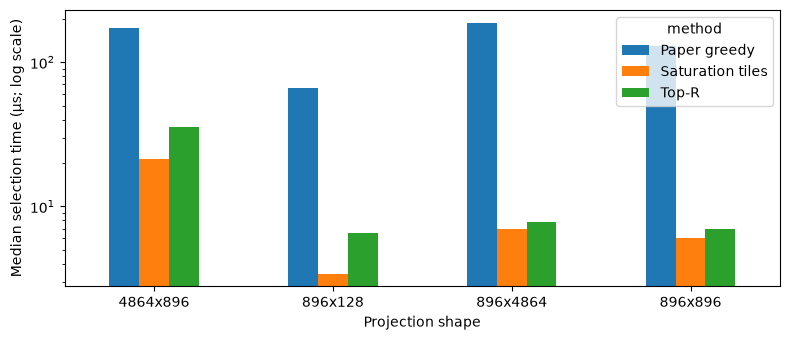

In [8]:
if not frame.empty:
    times = frame.pivot(index=["shape","trace_id","fraction"],columns="method",values="median_us")
    speedup = times[paper_methods].div(times["Saturation tiles"], axis=0)
    summary = frame.groupby(["shape","method"]).median_us.median().unstack()
    display(summary.round(3))
    display(speedup.groupby("shape").median().round(3).rename_axis(columns="Paper / Tiles"))
    ax = summary.plot.bar(figsize=(8,3.5),rot=0)
    ax.set(ylabel="Median selection time (µs; log scale)", xlabel="Projection shape", yscale="log")
    plt.tight_layout()
    plt.show()

## Pair speed and quality only where the budgets match.

The next summary uses the same exact-fill cases for all measured variants. Underfilled Paper has no fixed-$R$ quality gap, and is not assigned zero. Each point is a pair of medians across cases, not an individual mask or a Pareto frontier. The full timing comparison above still includes underfill.

,cases,exact_fill,median_fill_pct
method,,,
Paper greedy,1152,480,99.93146
Saturation tiles,1152,1152,100.00000
Top-R,1152,1152,100.00000


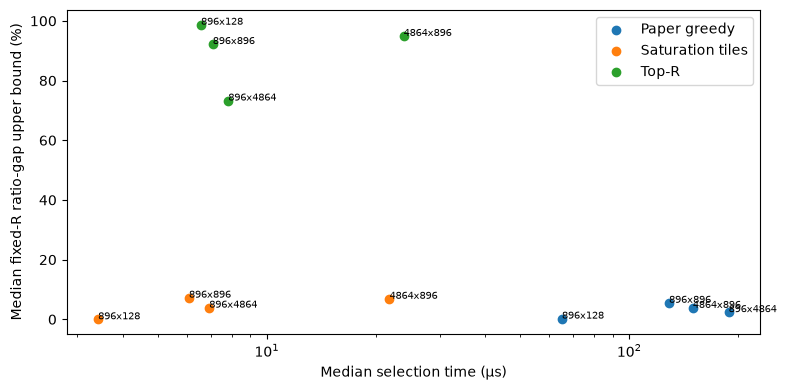

In [9]:
if not frame.empty:
    keys = ["trace_id","fraction"]
    eligible = frame[(frame.method == paper_methods[0]) & frame.gap_upper_pct.notna()][keys]
    matched = frame.merge(eligible,on=keys,validate="many_to_one")
    display(frame.groupby("method").agg(cases=("median_us","size"),
        exact_fill=("gap_upper_pct","count"), median_fill_pct=("fill_pct","median")))
    if not matched.empty:
        points = matched.groupby(["shape","method"])[["median_us","gap_upper_pct"]].median().reset_index()
        plt.figure(figsize=(8,4))
        for method, data in points.groupby("method"):
            plt.scatter(data.median_us,data.gap_upper_pct,label=method)
            for p in data.itertuples(): plt.annotate(p.shape,(p.median_us,p.gap_upper_pct),fontsize=7)
        plt.xscale("log")
        plt.xlabel("Median selection time (µs)")
        plt.ylabel("Median fixed-R ratio-gap upper bound (%)")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [10]:
if not frame.empty:
    for name in paper_methods:
        low, high = speedup[name].quantile([.05,.95])
        display(Markdown(
            f"Across **{len(times):,}** cases, **{name} / Tiles** has median **{speedup[name].median():.2f}×** "
            f"(5th–95th case percentiles **{low:.2f}–{high:.2f}×**)."))
    display(Markdown(f"**{int(frame.mask_matches_02.sum()):,}/{len(frame):,}** masks match Notebook 02 exactly; "
        "all passed selected-count, importance, and merged-cost checks."))

Across **1,152** cases, **Paper greedy / Tiles** has median **20.34×** (5th–95th case percentiles **7.07–30.26×**).

**3,456/3,456** masks match Notebook 02 exactly; all passed selected-count, importance, and merged-cost checks.

## Compose selection, read, and multiplication costs.

Join by the same trace, requested budget, actual selected count, and reference method. Both Paper variants use Paper's checked mask cost from Notebook 02. In milliseconds,

$$\widehat C_{j,m}=\widehat t_{j,m}/1000+\widehat L(M_{j,m}),\qquad
\boxed{\widehat T_{j,m}^{\rm projection}=\widehat C_{j,m}+\widehat G(p_j,|M_{j,m}|,d_j,\mathrm{dtype}).}$$

$\widehat G$ is the packed-GEMM median measured above. It is added only when present in the same run's CSV; legacy selection samples are never combined with a later GPU measurement. Without CUDA results, the report displays selection plus modeled I/O only.

[Figure 8](https://openreview.net/pdf?id=3xwsD68F2K) separates compute, I/O and selection, and the paper states that its evaluation does not overlap I/O and compute. This sum adopts a serial composition, **not** a reproduction of that full-model experiment. The submodule's `run.py` stores summed read timers as `measured_total`, not complete wall time; `native.cc` times weight upload separately from `io_us`. Here I/O remains Notebook 01's fitted profile, possibly from another device. Importance extraction, activation gathering, initial/final selector transfers, weight upload, bias, attention and other layers are absent. Therefore $\widehat T^{\rm projection}$ is not measured $T_{\rm wall}$.

On equal-count cases, identical packed-GEMM shapes share $G$, so adding it dilutes a partial speedup: $(C_P+G)/(C_T+G)$ approaches one as $G$ grows. Equal counts still do not establish equal importance or complete forward cost.

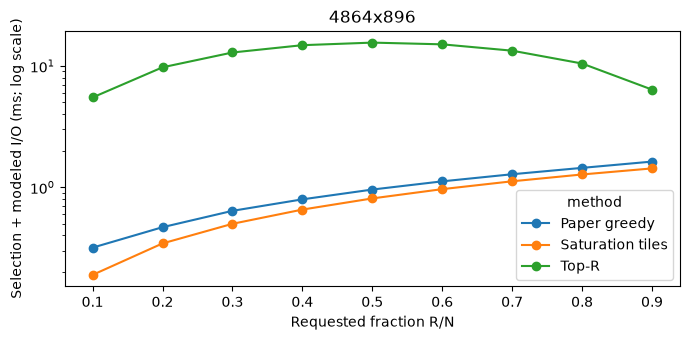

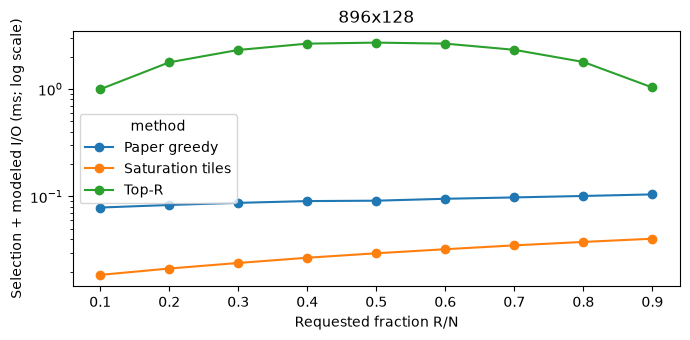

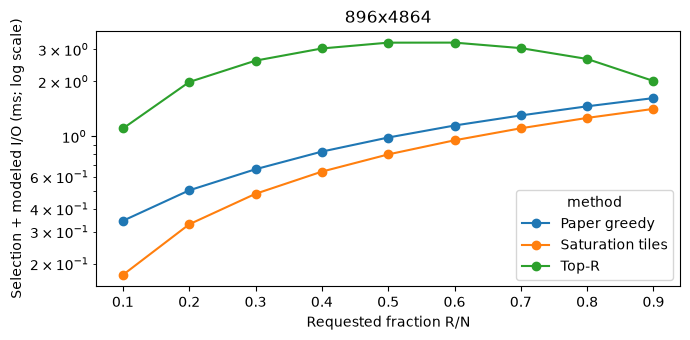

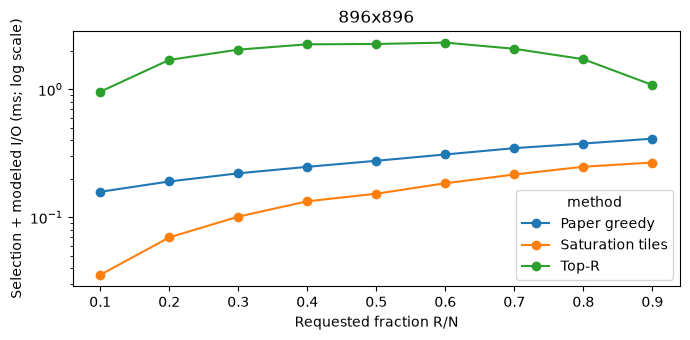

In [11]:
if not frame.empty:
    keys = ["shape", "trace_id", "fraction", "R_nominal", "R_selected", "reference_method"]
    io = pd.read_csv(QUALITY).rename(columns={"method": "reference_method", "latency": "modeled_io_ms"})
    io["fraction"] = io.fraction.round(6)
    reference = frame.method.where(~frame.method.str.startswith("Paper"), "Paper greedy")
    online = frame.assign(fraction=frame.fraction.round(6), reference_method=reference).merge(
        io[keys + ["modeled_io_ms"]], on=keys, how="left", validate="many_to_one")
    assert online.modeled_io_ms.notna().all(), "02 must contain the same cases and selected counts."
    online["selection_ms"] = online.median_us / 1000
    online["combined_ms"] = online.selection_ms + online.modeled_io_ms
    components = ["selection_ms", "modeled_io_ms"]
    metric = "combined_ms"
    if "matmul_ms" in online:
        assert online.matmul_ms.notna().all() and (online.matmul_ms > 0).all()
        online["projection_estimate_ms"] = online.combined_ms + online.matmul_ms
        components += ["matmul_ms"]
        metric = "projection_estimate_ms"
    label = "Selection + modeled I/O + packed GEMM" if "matmul_ms" in online else "Selection + modeled I/O"
    for shape, data in online.groupby("shape"):
        curves = data.groupby(["fraction", "method"])[metric].median().unstack()
        ax = curves.plot(marker="o", figsize=(7, 3.5), logy=True)
        ax.set(title=shape, xlabel="Requested fraction R/N", ylabel=label + " (ms; log scale)")
        plt.tight_layout()
        plt.show()

The curves summarize all saved cases at each requested budget, including Paper underfill. They are not equal-importance comparisons. The table below instead uses only cases where Paper fills the requested $R$, paired across all methods. Equal counts match row volume, not necessarily importance or compute time. Each column is a median across those same cases; the final column is the median of per-case sums, not a sum of marginal medians. CPU and GPU-sort Paper are reported separately. This is a same-count comparison, not a matched-accuracy speedup.

In [12]:
if not frame.empty:
    case = ["shape", "trace_id", "fraction", "R_nominal"]
    paper_rows = online[online.method == paper_methods[0]]
    filled = paper_rows[paper_rows.R_selected == paper_rows.R_nominal][case]
    exact = online.merge(filled, on=case, validate="many_to_one")
    if not exact.empty:
        display(exact.groupby("method")[components + [metric]].median().round(4))
        paired = exact.pivot(index=case, columns="method", values=metric)
        for name in paper_methods:
            ratio = paired[name] / paired["Saturation tiles"]
            saving = paired[name] - paired["Saturation tiles"]
            display(Markdown(
                f"On **{len(paired):,}/{len(paper_rows):,}** exact-fill cases, Tiles cost less than **{name}** in "
                f"**{int((saving > 0).sum()):,}/{len(paired):,}** pairs. Median paired ratio: "
                f"**{ratio.median():.2f}×**; saving: **{saving.median():.3f} ms**. "
                f"Metric: {label}. This is a composed estimate, not measured wall time or equal-quality gain."))
    else:
        display(Markdown("No Paper exact-fill cases are available for a paired cost comparison."))
    higher = paper_rows[paper_rows.fraction > 0.1]
    if not higher.empty:
        display(Markdown(
            f"Above the 10% requested budget, Paper's median fill is **{higher.fill_pct.median():.2f}%**; "
            f"**{100 * higher.fill_pct.ge(95).mean():.2f}%** of cases fill at least 95%. "
            "Near-full cases remain outside the exact-fill table; their trade-offs stay in the curves."))

,selection_ms,modeled_io_ms,combined_ms
method,,,
Paper greedy,0.1655,0.3345,0.5053
Saturation tiles,0.0067,0.3226,0.3439
Top-R,0.0078,2.6750,2.6815


On **480/1,152** exact-fill cases, Tiles cost less than **Paper greedy** in **480/480** pairs. Median paired ratio: **1.41×**; saving: **0.166 ms**. Metric: Selection + modeled I/O. This is a composed estimate, not measured wall time or equal-quality gain.

Above the 10% requested budget, Paper's median fill is **99.93%**; **96.88%** of cases fill at least 95%. Near-full cases remain outside the exact-fill table; their trade-offs stay in the curves.

The timed selector calls have CPU-resident input and output. Only Paper's score sorting optionally uses CUDA; tiles remain C++ CPU. The CUDA experiment also measures a shape-equivalent packed GEMM, using archived token counts and actual selected rows. No extra VLM runtime or SSD benchmark is introduced. The saved I/O model is still an assumption when forming the projection estimate, and omitted costs must not be called zero.

The legacy CSV predates explicit per-method sort labels. Its environment file contains a hard-coded `cuda_sort=False` although the HEAD call passed `True`; that run's actual sort device cannot be established from this metadata. The file is preserved, not relabelled as verified CPU or GPU evidence. New runs record both variants explicitly, the CUDA runtime, GPU, dtype, and raw GEMM samples.

Sources: [Notebook 02](../02/02_global_oracle.ipynb), [reference policy](../../../upstream/vlm-flash/src/vlmflash/policy.py), [native selector and read timers](../../../upstream/vlm-flash/src/vlmflash/csrc/native.cc), [flash-path multiplication](../../../upstream/vlm-flash/src/vlmflash/linear.py), [I/O-only run aggregation](../../../upstream/vlm-flash/scripts/run.py), and [PyTorch CUDA timing](https://docs.pytorch.org/docs/2.10/notes/cuda.html#asynchronous-execution).